In [1]:
import os

PROJECT_DIR = "/content/drive/MyDrive/AI_Text_Detector"

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "dataset"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "model",
    "bert_ai_detector"
)

CHECKPOINT_DIR = os.path.join(
    PROJECT_DIR,
    "model",
    "checkpoints"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("===== PROJECT PATHS =====")
print("Project   :", PROJECT_DIR)
print("Dataset   :", DATASET_DIR)
print("Model     :", MODEL_DIR)
print("Checkpoint:", CHECKPOINT_DIR)
print("Results   :", RESULTS_DIR)

===== PROJECT PATHS =====
Project   : /content/drive/MyDrive/AI_Text_Detector
Dataset   : /content/drive/MyDrive/AI_Text_Detector\dataset
Model     : /content/drive/MyDrive/AI_Text_Detector\model\bert_ai_detector
Checkpoint: /content/drive/MyDrive/AI_Text_Detector\model\checkpoints
Results   : /content/drive/MyDrive/AI_Text_Detector\results


In [2]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Project paths
PROJECT_DIR = "/content/drive/MyDrive/AI_Text_Detector"
DATASET_DIR = f"{PROJECT_DIR}/dataset"
MODEL_DIR = f"{PROJECT_DIR}/model/bert_ai_detector"

# Check folders
print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATASET_DIR)
print("Model directory:", MODEL_DIR)

print("\nDataset folder exists:", os.path.exists(DATASET_DIR))
print("Model folder exists:", os.path.exists(MODEL_DIR))

ModuleNotFoundError: No module named 'google.colab'

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/AI_Text_Detector"

DATASET_DIR = f"{PROJECT_DIR}/dataset"
MODEL_DIR = f"{PROJECT_DIR}/model/bert_ai_detector"

print("Project directory:", PROJECT_DIR)
print("Dataset directory:", DATASET_DIR)
print("Model directory:", MODEL_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/AI_Text_Detector
Dataset directory: /content/drive/MyDrive/AI_Text_Detector/dataset
Model directory: /content/drive/MyDrive/AI_Text_Detector/model/bert_ai_detector


In [ ]:
import os
import pandas as pd

train_path = f"{DATASET_DIR}/train.csv"
val_path = f"{DATASET_DIR}/validation.csv"
test_path = f"{DATASET_DIR}/test.csv"

print("Train exists:", os.path.exists(train_path))
print("Validation exists:", os.path.exists(val_path))
print("Test exists:", os.path.exists(test_path))

Train exists: True
Validation exists: True
Test exists: True


In [ ]:
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (8000, 2)
Validation shape: (1000, 2)
Test shape: (1000, 2)


In [ ]:
print("Training labels:")
print(train_df["label"].value_counts())

print("\nValidation labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

Training labels:
label
0    4000
1    4000
Name: count, dtype: int64

Validation labels:
label
1    500
0    500
Name: count, dtype: int64

Test labels:
label
1    500
0    500
Name: count, dtype: int64


In [ ]:
!pip install --upgrade --no-cache-dir pyarrow

In [ ]:
import pyarrow
import datasets

print("PyArrow:", pyarrow.__version__)
print("Datasets:", datasets.__version__)

PyArrow: 25.0.1
Datasets: 5.0.1


In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not enabled.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
from transformers import BertTokenizer

MODEL_NAME = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully!")
print("Model:", MODEL_NAME)

Tokenizer loaded successfully!
Model: bert-base-uncased


In [ ]:
!pip install --force-reinstall --no-cache-dir pyarrow==17.0.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 78.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.2
    Uninstalling numpy-2.5.2:
      Successfully uninstalled numpy-2.5.2
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 25.0.1
    Uninstalling pyarrow-25.0.1:
      Successfully uninstalled pyarrow-25.0.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 5.0.1 requires pyarrow>=21.0.0, but you have pyarrow 17.0.0 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.2 which is incompatible.


In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]],
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df[["text", "label"]],
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False
)

print("Train:", train_dataset)
print("Validation:", val_dataset)
print("Test:", test_dataset)

Train: Dataset({
    features: ['text', 'label'],
    num_rows: 8000
})
Validation: Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})
Test: Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})


In [ ]:
from transformers import BertTokenizer

MODEL_NAME = "bert-base-uncased"

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)

print("Tokenizer loaded successfully!")
print("Model:", MODEL_NAME)

Tokenizer loaded successfully!
Model: bert-base-uncased


In [ ]:
MAX_LENGTH = 256

def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization completed!")

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenization completed!


In [ ]:
print("Train:", len(train_tokenized))
print("Validation:", len(val_tokenized))
print("Test:", len(test_tokenized))

print("\nColumns:")
print(train_tokenized.column_names)

print("\nFirst sample:")
print(train_tokenized[0])

Train: 8000
Validation: 1000
Test: 1000

Columns:
['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']

First sample:
{'text': 'none of the above you mentioned , while resistants varies from person to person as what s called " glass jaw " the biggest thing to geting knocked out is right hit in the right place , knocking out happens when brain hits the side of the skull , most easyst way to knock out a person is a right hit on a jaw , that s why boxers protect the jaw , from geting knocked out they simply protect the places that get you knocked out , when they fail to do so and oponent lands a hit a boxer usuly falls down to the ground .', 'label': 0, 'input_ids': [101, 3904, 1997, 1996, 2682, 2017, 3855, 1010, 2096, 13070, 2015, 9783, 2013, 2711, 2000, 2711, 2004, 2054, 1055, 2170, 1000, 3221, 5730, 1000, 1996, 5221, 2518, 2000, 2131, 2075, 6573, 2041, 2003, 2157, 2718, 1999, 1996, 2157, 2173, 1010, 10591, 2041, 6433, 2043, 4167, 4978, 1996, 2217, 1997, 1996, 7412, 1010, 

In [ ]:
train_tokenized = train_tokenized.remove_columns(["text"])
val_tokenized = val_tokenized.remove_columns(["text"])
test_tokenized = test_tokenized.remove_columns(["text"])

print("Columns after removing text:")
print(train_tokenized.column_names)

Columns after removing text:
['label', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
train_tokenized = train_tokenized.rename_column("label", "labels")
val_tokenized = val_tokenized.rename_column("label", "labels")
test_tokenized = test_tokenized.rename_column("label", "labels")

print("Final columns:")
print(train_tokenized.column_names)

Final columns:
['labels', 'input_ids', 'token_type_ids', 'attention_mask']


In [ ]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

print("BERT model loaded successfully!")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded successfully!


In [ ]:
model.config.id2label = {
    0: "HUMAN",
    1: "AI_GENERATED"
}

model.config.label2id = {
    "HUMAN": 0,
    "AI_GENERATED": 1
}

print(model.config.id2label)

{0: 'HUMAN', 1: 'AI_GENERATED'}


In [ ]:
print("Number of labels:", model.config.num_labels)
print("Labels:", model.config.id2label)

Number of labels: 2
Labels: {0: 'HUMAN', 1: 'AI_GENERATED'}


In [ ]:
from transformers import TrainingArguments

import os
os.makedirs(MODEL_DIR, exist_ok=True)

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,

    # Training
    num_train_epochs=3,
    learning_rate=2e-5,
    weight_decay=0.01,

    # Batch sizes
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    # Evaluation
    eval_strategy="epoch",

    # Checkpoint saving
    save_strategy="epoch",
    save_total_limit=2,

    # Automatically restore the best checkpoint
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Performance
    fp16=True,

    # Logging
    logging_strategy="steps",
    logging_steps=50,

    # Reproducibility
    seed=42,

    # Don't send results to external tracking services
    report_to="none"
)

print("Training configuration created successfully!")

Training configuration created successfully!


In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

print("Data collator created successfully!")

Data collator created successfully!


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

print("Metrics function ready!")

Metrics function ready!


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

Trainer created successfully!


In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nTraining samples:", len(train_tokenized))
print("Validation samples:", len(val_tokenized))
print("Test samples:", len(test_tokenized))

print("\nModel:", MODEL_NAME)
print("Max sequence length:", MAX_LENGTH)
print("Epochs:", training_args.num_train_epochs)
print("Training batch size:", training_args.per_device_train_batch_size)
print("Gradient accumulation:", training_args.gradient_accumulation_steps)
print("Output directory:", MODEL_DIR)

CUDA available: True
GPU: Tesla T4

Training samples: 8000
Validation samples: 1000
Test samples: 1000

Model: bert-base-uncased
Max sequence length: 256
Epochs: 3
Training batch size: 8
Gradient accumulation: 2
Output directory: /content/drive/MyDrive/AI_Text_Detector/model/bert_ai_detector


In [ ]:
import os
import glob

# Check whether a previous checkpoint exists
checkpoints = glob.glob(
    os.path.join(MODEL_DIR, "checkpoint-*")
)

if checkpoints:
    checkpoints = sorted(
        checkpoints,
        key=lambda x: int(x.split("-")[-1])
    )

    latest_checkpoint = checkpoints[-1]

    print("Previous checkpoint found:")
    print(latest_checkpoint)
    print("\nResuming training from checkpoint...")

    trainer.train(
        resume_from_checkpoint=latest_checkpoint
    )

else:
    print("No previous checkpoint found.")
    print("Starting BERT training from the beginning...")

    trainer.train()

Previous checkpoint found:
/content/drive/MyDrive/AI_Text_Detector/model/bert_ai_detector/checkpoint-1500

Resuming training from checkpoint...


[transformers] You are resuming training from a checkpoint trained with 5.13.1 of Transformers but your current version is 5.15.1. This is not recommended and could yield to errors or unwanted behaviors.
[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attentio

Epoch,Training Loss,Validation Loss


In [ ]:
import os

os.makedirs(MODEL_DIR, exist_ok=True)

# Save the best model
trainer.save_model(MODEL_DIR)

# Save tokenizer
tokenizer.save_pretrained(MODEL_DIR)

print("===================================")
print("BERT MODEL SAVED SUCCESSFULLY")
print("===================================")
print("Model location:")
print(MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT MODEL SAVED SUCCESSFULLY
Model location:
/content/drive/MyDrive/AI_Text_Detector/model/bert_ai_detector


In [ ]:
test_results = trainer.evaluate(
    eval_dataset=test_tokenized
)

print("===== TEST RESULTS =====")

for key, value in test_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000113,0.021147,3,0.997000,0.996008,0.998000,0.997003


===== TEST RESULTS =====
eval_loss: 0.0211
eval_accuracy: 0.9970
eval_precision: 0.9960
eval_recall: 0.9980
eval_f1: 0.9970


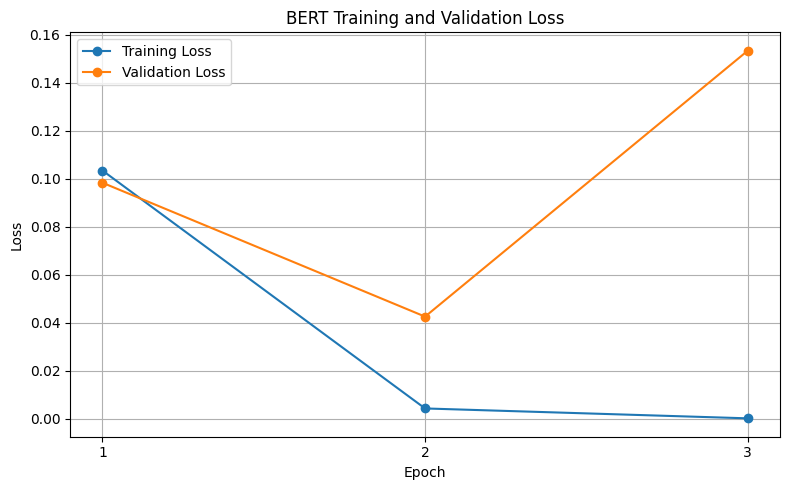

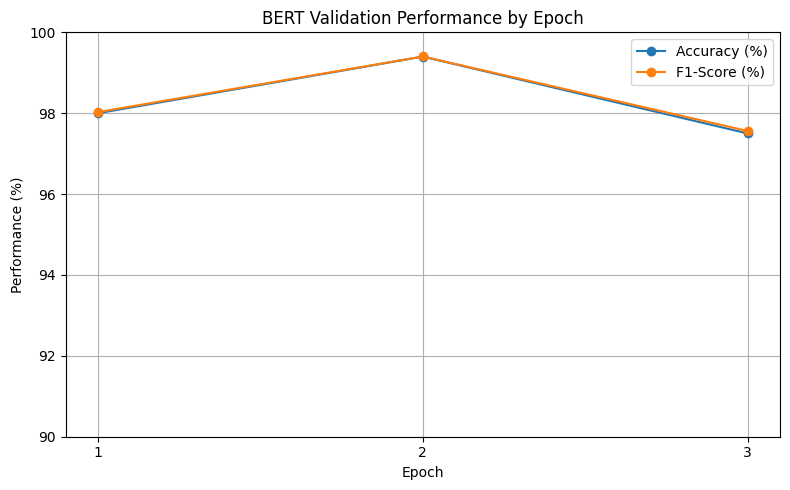

Graphs saved successfully!
/content/drive/MyDrive/AI_Text_Detector/results/training_validation_loss.png
/content/drive/MyDrive/AI_Text_Detector/results/validation_metrics.png


In [ ]:
import matplotlib.pyplot as plt
import os

# Training history from our completed BERT training
epochs = [1, 2, 3]

training_loss = [
    0.103470,
    0.004240,
    0.000113
]

validation_loss = [
    0.098376,
    0.042536,
    0.153430
]

accuracy = [
    98.0,
    99.4,
    97.5
]

f1_score = [
    98.0276,
    99.4024,
    97.5610
]

RESULTS_DIR = f"{PROJECT_DIR}/results"
os.makedirs(RESULTS_DIR, exist_ok=True)


# ==========================================
# GRAPH 1: TRAINING VS VALIDATION LOSS
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    training_loss,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("BERT Training and Validation Loss")
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.tight_layout()

loss_path = f"{RESULTS_DIR}/training_validation_loss.png"

plt.savefig(
    loss_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ==========================================
# GRAPH 2: ACCURACY AND F1
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    accuracy,
    marker="o",
    label="Accuracy (%)"
)

plt.plot(
    epochs,
    f1_score,
    marker="o",
    label="F1-Score (%)"
)

plt.xlabel("Epoch")
plt.ylabel("Performance (%)")
plt.title("BERT Validation Performance by Epoch")
plt.xticks(epochs)
plt.ylim(90, 100)
plt.legend()
plt.grid(True)

plt.tight_layout()

metrics_path = f"{RESULTS_DIR}/validation_metrics.png"

plt.savefig(
    metrics_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("Graphs saved successfully!")
print(loss_path)
print(metrics_path)

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

predictions = trainer.predict(test_tokenized)

predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

true_labels = predictions.label_ids

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=["Human", "AI-Generated"],
        digits=4
    )
)

              precision    recall  f1-score   support

       Human     0.9980    0.9960    0.9970       500
AI-Generated     0.9960    0.9980    0.9970       500

    accuracy                         0.9970      1000
   macro avg     0.9970    0.9970    0.9970      1000
weighted avg     0.9970    0.9970    0.9970      1000



Confusion Matrix:
[[498   2]
 [  1 499]]


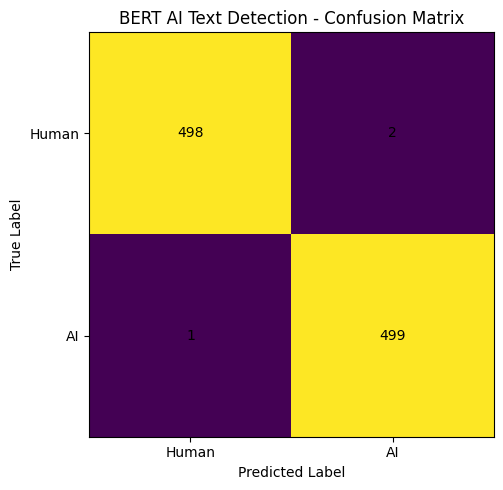

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_labels,
    predicted_labels
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("BERT AI Text Detection - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Human", "AI"]
)

plt.yticks(
    [0, 1],
    ["Human", "AI"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

In [ ]:
print("===== CHECKING TEST RESULTS =====")

print("Type:", type(test_results))

if isinstance(test_results, dict):
    print("Keys:", test_results.keys())
    print("Contents:", test_results)
else:
    print("Value:", test_results)

===== CHECKING TEST RESULTS =====
Type: <class 'dict'>
Keys: dict_keys(['eval_loss', 'eval_accuracy', 'eval_precision', 'eval_recall', 'eval_f1'])
Contents: {'eval_loss': 0.021147264167666435, 'eval_accuracy': 0.997, 'eval_precision': 0.9960079840319361, 'eval_recall': 0.998, 'eval_f1': 0.997002997002997}


In [ ]:
import json
import os

results_path = f"{PROJECT_DIR}/results"
os.makedirs(results_path, exist_ok=True)

# Save test metrics
with open(
    f"{results_path}/test_metrics.json",
    "w"
) as f:
    json.dump(
        {
            key: float(value)
            for key, value in test_results.items()
        },
        f,
        indent=4
    )

print("===== TEST METRICS SAVED =====")
print("Location:", results_path)
print("Metrics:", test_results)

===== TEST METRICS SAVED =====
Location: /content/drive/MyDrive/AI_Text_Detector/results
Metrics: {'eval_loss': 0.021147264167666435, 'eval_accuracy': 0.997, 'eval_precision': 0.9960079840319361, 'eval_recall': 0.998, 'eval_f1': 0.997002997002997}


In [ ]:
import numpy as np
import os

results_path = f"{PROJECT_DIR}/results"
os.makedirs(results_path, exist_ok=True)

print("===== SAVING CONFUSION MATRIX =====")

np.savetxt(
    f"{results_path}/confusion_matrix.csv",
    cm,
    delimiter=",",
    fmt="%d"
)

print("Confusion matrix saved successfully!")
print("Location:", results_path)
print("Matrix:")
print(cm)

===== SAVING CONFUSION MATRIX =====
Confusion matrix saved successfully!
Location: /content/drive/MyDrive/AI_Text_Detector/results
Matrix:
[[498   2]
 [  1 499]]


In [ ]:
print("===== SAVING FINAL MODEL TO GOOGLE DRIVE =====")

import os

os.makedirs(MODEL_DIR, exist_ok=True)

# Save trained model
trainer.save_model(MODEL_DIR)

# Save tokenizer
tokenizer.save_pretrained(MODEL_DIR)

print("===== FINAL MODEL SAVED =====")
print("Model location:", MODEL_DIR)

===== SAVING FINAL MODEL TO GOOGLE DRIVE =====


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

===== FINAL MODEL SAVED =====
Model location: /content/drive/MyDrive/AI_Text_Detector/model/bert_ai_detector


In [ ]:
import os

MODEL_PATH = "/content/drive/MyDrive/AI_Text_Detector/model/bert_ai_detector"

print("===== CHECKING TRAINED MODEL =====")

if os.path.exists(MODEL_PATH):
    print("✅ Model folder exists!")
    print("\nFiles inside model folder:")
    print(os.listdir(MODEL_PATH))
else:
    print("❌ Model folder does NOT exist.")

===== CHECKING TRAINED MODEL =====
✅ Model folder exists!

Files inside model folder:
[]


In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/AI_Text_Detector"

print("===== CHECKING PROJECT DRIVE =====")

for root, dirs, files in os.walk(PROJECT_DIR):
    level = root.replace(PROJECT_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}  {file}")

===== CHECKING PROJECT DRIVE =====
AI_Text_Detector/
  dataset/
    processed_dataset.csv
    test.csv
    validation.csv
    train.csv
    final_dataset/
  model/
    bert_ai_detector/
      config.json
      model.safetensors
      tokenizer_config.json
      tokenizer.json
      training_args.bin
      checkpoint-1000/
        config.json
        model.safetensors
        tokenizer_config.json
        tokenizer.json
        training_args.bin
        optimizer.pt
        scheduler.pt
        scaler.pt
        rng_state.pth
        trainer_state.json
      checkpoint-1500/
        config.json
        model.safetensors
        tokenizer_config.json
        tokenizer.json
        training_args.bin
        optimizer.pt
        scheduler.pt
        scaler.pt
        rng_state.pth
        trainer_state.json
    checkpoints/
  notebooks/
    01_dataset_preparation.ipynb
    02_bert_training.ipynb
  backend/
  frontend/
  results/
    classification_report.txt
    confusion_matrix.csv
    te

In [ ]:
import os

PROJECT_DIR = "/content/drive/MyDrive/AI_Text_Detector"

DATASET_DIR = os.path.join(
    PROJECT_DIR,
    "dataset"
)

MODEL_DIR = os.path.join(
    PROJECT_DIR,
    "model",
    "bert_ai_detector"
)

RESULTS_DIR = os.path.join(
    PROJECT_DIR,
    "results"
)

os.makedirs(DATASET_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("===== PROJECT FOLDERS CREATED =====")
print("Dataset :", DATASET_DIR)
print("Model   :", MODEL_DIR)
print("Results :", RESULTS_DIR)

===== PROJECT FOLDERS CREATED =====
Dataset : /content/drive/MyDrive/AI_Text_Detector/dataset
Model   : /content/drive/MyDrive/AI_Text_Detector/model/bert_ai_detector
Results : /content/drive/MyDrive/AI_Text_Detector/results


In [ ]:
print("===== COPYING TRAINED MODEL TO GOOGLE DRIVE =====")

import shutil
import os

SOURCE_MODEL = "/content/bert_ai_detector"

if os.path.exists(SOURCE_MODEL):
    shutil.copytree(
        SOURCE_MODEL,
        MODEL_DIR,
        dirs_exist_ok=True
    )
    print("✅ Model copied successfully!")
    print("Model location:", MODEL_DIR)
    print("Files:", os.listdir(MODEL_DIR))
else:
    print("❌ Source model not found:", SOURCE_MODEL)

===== COPYING TRAINED MODEL TO GOOGLE DRIVE =====
❌ Source model not found: /content/bert_ai_detector


In [ ]:
import os

print("===== VERIFYING MODEL IN GOOGLE DRIVE =====")

print("Model path:")
print(MODEL_DIR)

if os.path.exists(MODEL_DIR):
    files = os.listdir(MODEL_DIR)

    print("\nNumber of files:", len(files))

    for file in files:
        print("✓", file)

    if len(files) > 0:
        print("\n✅ TRAINED MODEL IS SAVED IN GOOGLE DRIVE")
    else:
        print("\n❌ MODEL FOLDER IS EMPTY")
else:
    print("\n❌ MODEL FOLDER DOES NOT EXIST")

===== VERIFYING MODEL IN GOOGLE DRIVE =====
Model path:
/content/drive/MyDrive/AI_Text_Detector/model/bert_ai_detector

Number of files: 7
✓ checkpoint-1000
✓ checkpoint-1500
✓ config.json
✓ model.safetensors
✓ tokenizer_config.json
✓ tokenizer.json
✓ training_args.bin

✅ TRAINED MODEL IS SAVED IN GOOGLE DRIVE
